##  Dataset Description
We have a large number of Wikipedia comments which have been labeled by human raters for toxic behavior. The types of toxicity are:


*   Toxic
*   Severe_toxic
*   Obscene
*   Threat
*   Insult
*   Identity_hate






In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [91]:
df = pd.read_csv("train.csv")
df.sample(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
143740,01f81806e27ef8ab,"""Under section """"Rewrote lead"""". Let's discuss...",0,0,0,0,0,0
125754,a0b8752c60fb1a6a,February 2011 (UTC)\nI didn't think there woul...,0,0,0,0,0,0
111115,526b2be52aace3bb,"talk page boxes \n\nFYI, your table of content...",0,0,0,0,0,0
85237,e40467d16661d42c,"""\n\n Having placed the template on your page...",0,0,0,0,0,0
114387,63c971a1df70cf3e,"""\n\nHi, I am new to Wikipedia and I am not su...",0,0,0,0,0,0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [94]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [95]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

example_rows = []

for col in labels:
    row = df[(df[col] == 1) & (df.iloc[:, 2:].sum(axis=1) == 1)].head(1)
    example_rows.append(row)

uniques = pd.concat(example_rows).reset_index(drop=True)
uniques

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0005c987bdfc9d4b,Hey... what is it..\n@ | talk .\nWhat is it......,1,0,0,0,0,0
1,01625cc84c6ef15b,How do you know he is dead. Its just his plan...,0,0,1,0,0,0
2,09eb7d87b8c24ca5,Please stop. If you continue to ignore our pol...,0,0,0,1,0,0
3,006d11791d76b9f3,"REPLY ABOVE:\nThat was me, loser. The UN defin...",0,0,0,0,1,0
4,09b51ed1ee5e29a1,"Mate, sound like you are jewish\n\nGayness is ...",0,0,0,0,0,1


In [96]:
uniques['comment_text'][0]

'Hey... what is it..\n@ | talk .\nWhat is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?\n\nAsk Sityush to clean up his behavior than issue me nonsensical warnings...'

In [97]:
x = df.iloc[:, 2:].sum()
x

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


In [98]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

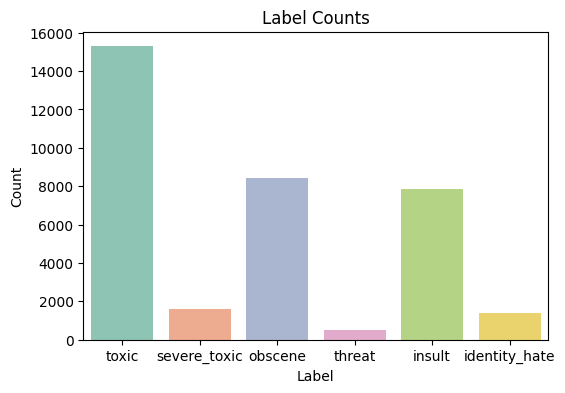

In [99]:
plt.figure(figsize = (6,4))
sns.barplot(x = x.index, y = x.values, alpha = 0.8,palette="Set2")
plt.title("Label Counts")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

In [100]:
df.sample(2)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
151347,7ba7c886dceabe09,foot fetishes are awesome fuck you 68.228.72.192,1,0,1,0,1,0
39725,6a13099c3af29cdb,|decline=Explain this and this then. You're al...,0,0,0,0,0,0


In [101]:
rowsum =df.iloc[:,2:].sum(axis=1)
rowsum

,0
0,0
1,0
2,0
3,0
4,0
...,...
159566,0
159567,0
159568,0
159569,0


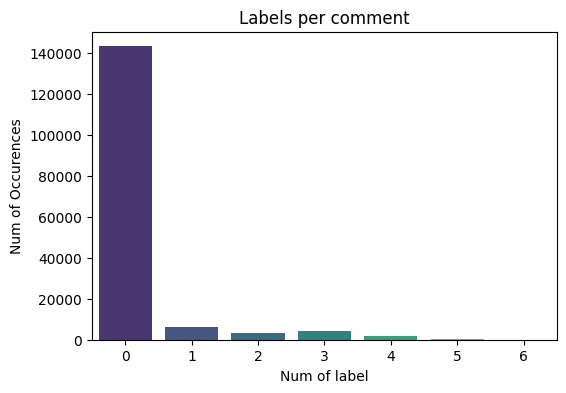

In [102]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = rowsum.values,palette="viridis")
plt.title("Labels per comment")
plt.ylabel("Num of Occurences")
plt.xlabel("Num of label")
plt.show()

## Data preprocessing

In [103]:
df.drop(columns="id",inplace=True)
df

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...
159566,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [104]:
# Stop Words removal
stopwords = set(stopwords.words("english"))
def remove_stopwords(text):
    no_stopwords_text = [w for w in text.split() if not w in stopwords]
    return " ".join(no_stopwords_text)

In [105]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub('\W', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip(' ')
    return text

def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub('\W', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip(' ')
    return text


stemmer = SnowballStemmer('english')
def stemming(sentence):
    stemmed_sentence = ""
    for word in sentence.split():
        stemmed_word = stemmer.stem(word)
        stemmed_sentence += stemmed_word + " "

    stemmed_sentence = stemmed_sentence.strip()
    return stemmed_sentence



In [106]:
df["comment_text"] = df["comment_text"].apply(lambda x: remove_stopwords(x))
df["comment_text"] = df["comment_text"].apply(lambda x: clean_text(x))
df["comment_text"] = df["comment_text"].apply(lambda x: stemming(x))

In [107]:
X = df["comment_text"]
y = df.drop(columns=["comment_text"],axis=1)

In [108]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [109]:
def run_pipeline(pipeline,X_train,X_test,y_train,y_test):
    # Training the model
    pipeline.fit(X_train,y_train)
    # Predict from model
    predictions = pipeline.predict(X_test)
    pred_probs = pipeline.predict_proba(X_test)
    # print accuracy
    print("Accuracy : ", accuracy_score(y_test,predictions))

In [110]:
from sklearn.multiclass import OneVsRestClassifier
LR_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rb_model', OneVsRestClassifier(LogisticRegression(), n_jobs=-1))
])

In [111]:
run_pipeline(LR_pipeline,X_train,X_test,y_train,y_test)

Accuracy :  0.9180322732257559


In [112]:
labels = y_train.columns.values

In [113]:
sentence = "how are you doing"
stemmed_sentence = stemming(sentence)
results = LR_pipeline.predict([stemmed_sentence])[0]
for label,result in zip(labels,results):
    print(label,"---" ,result)


toxic --- 0
severe_toxic --- 0
obscene --- 0
threat --- 0
insult --- 0
identity_hate --- 0


In [117]:
sentence = "I hate working late after office, that kills all my excitment for working next day"
stemmed_stentence = stemming(sentence)
results = LR_pipeline.predict([stemmed_stentence])[0]
for label,result in zip(labels,results):
    print(label,"---" ,result)

toxic --- 1
severe_toxic --- 0
obscene --- 0
threat --- 0
insult --- 0
identity_hate --- 0


In [118]:
sentence = "I will kill everyone one day"
stemmed_stentence = stemming(sentence)
results = LR_pipeline.predict([stemmed_stentence])[0]
for label,result in zip(labels,results):
    print(label,"---" ,result)

toxic --- 1
severe_toxic --- 0
obscene --- 0
threat --- 1
insult --- 0
identity_hate --- 0


In [114]:
sentence = "Thank You for the help, i really appreciate your contribution!"
stemmed_sentence = stemming(sentence)
results = LR_pipeline.predict([stemmed_sentence])[0]
for label,result in zip(labels,results):
    print(label,"---" ,result)

toxic --- 0
severe_toxic --- 0
obscene --- 0
threat --- 0
insult --- 0
identity_hate --- 0
